# Oil Is Equity in a Mirror — a quantitative teardown 🔬

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Mirror?: Busted](https://img.shields.io/badge/Mirror%3F-Busted-8b949e?style=flat-square)

**Claim.** Equities show the leverage effect (Black 1976; Christie 1982): volatility responds
more to negative than to positive return shocks. Commodities, oil among them, are said to
show the **inverse** asymmetry — volatility responds more to *positive* shocks — because the
shocks that matter are supply disruptions that spike prices. **Test.** GJR-GARCH(1,1,1) and
EGARCH(1,1,1) with robust SEs; a model-free forward-realised-vol regression split by return
sign (Newey-West); a pre-registered two-era split; a rolling 3-year GJR; skewness; a
monthly-average Brent cross-check; a vol-target overlay on WTI and the S&P, one lag, costs.

**Sign convention used everywhere:** the *inverse score* is positive when volatility rises
more after rallies (the claim), negative for the equity sign.

> 💡 **In plain words:** we ask the same question four different ways and then ask
> whether the answer would change how you run a volatility-target strategy.

In [1]:
import sys, os, warnings
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
warnings.filterwarnings("ignore")
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 90
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
OIL, EQ, NULL = "#eb6834", "#2a78d6", "#8b949e"     # oil = orange, equity = blue
from mirrorlev import data, strategy as st

## Verdict, up front

| | Stamp | Decisive numbers |
|---|---|---|
| Signal | **None** | WTI 1986-2018 GJR inverse *t* = -2.62, EGARCH -4.40, model-free -1.28; eras -0.15 / -4.81 (z of difference +3.38) |
| Tradability | **Mirage** | WTI overlay net Sharpe gain -0.08 (S&P +0.02); spot tape non-investable |

## 1 · Hypotheses (pre-registered in `strategy.verdict`)

- **H1 (Real):** full-sample WTI GJR inverse *t* ≥ 2 **and** model-free *t*(b_up − b_dn) ≥ 2 at
  *h* = 21.
- **H2 (Mixed — regime):** in the pre-registered eras 1986-2007 / 2008-2018, one era has inverse
  *t* ≥ 2 and the other ≤ −2 (or ≥ 2 vs an equity-signed estimate with |z| ≥ 2 on the
  difference).
- **Weak:** one lens or one era clears 2. **None:** otherwise.
- **Tradability:** never Investable (spot). Fragile iff the WTI overlay beats buy-and-hold on
  net excess Sharpe *and* drawdown; else Mirage.

## 2 · The machinery works (synthetic, NOT evidence)

A GJR(1,1,1) with Student-t(8) shocks, 30% vol, persistence 0.97; `signal_strength` k sets
gamma = 0.10·k. k = +1 is equity-type, −1 the mirror, 0 symmetric.

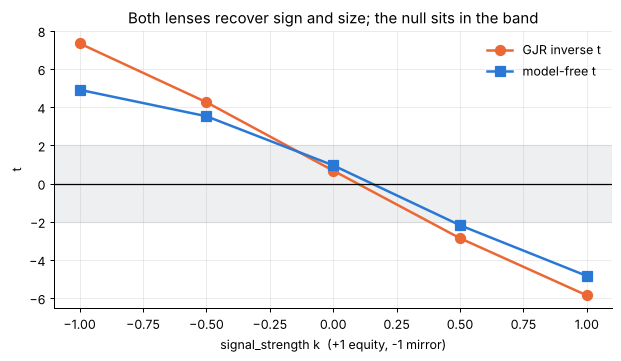

,gamma_true,gamma_hat,gjr_inv_t,egarch_inv_t,mf_t
k,,,,,
1.000,0.100,0.088,-5.859,-5.845,-4.840
0.500,0.050,0.039,-2.864,-2.744,-2.184
0.000,0.000,-0.008,0.677,0.644,0.953
-0.500,-0.050,-0.054,4.261,3.995,3.527
-1.000,-0.100,-0.100,7.342,6.952,4.911


In [2]:
rows = []
for k in (1.0, 0.5, 0.0, -0.5, -1.0):
    px, tr = data.synthetic_gjr(n_years=20, signal_strength=k, seed=1027)
    r = data.log_returns(px)
    g, e = st.fit_asymmetry(r, "gjr"), st.fit_asymmetry(r, "egarch")
    m = st.forward_vol_regression(r, 21)
    rows.append({"k": k, "gamma_true": tr["gamma"], "gamma_hat": g["gamma"],
                 "gjr_inv_t": g["inv_t"], "egarch_inv_t": e["inv_t"], "mf_t": m["diff_t"]})
cal = pd.DataFrame(rows).set_index("k")
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(cal.index, cal["gjr_inv_t"], "o-", color=OIL, lw=2, ms=8, label="GJR inverse t")
ax.plot(cal.index, cal["mf_t"], "s-", color=EQ, lw=2, ms=8, label="model-free t")
ax.axhspan(-2, 2, color=NULL, alpha=0.15); ax.axhline(0, color="k", lw=1)
ax.set_xlabel("signal_strength k  (+1 equity, -1 mirror)"); ax.set_ylabel("t")
ax.legend(frameon=False); ax.set_title("Both lenses recover sign and size; the null sits in the band")
plt.show(); cal.round(3)

> 💡 **In plain words:** when we *plant* the mirror, the tools find it loudly; when we
> plant the stock pattern, they find that with the opposite sign; when we plant nothing, they
> find nothing. So a "no" on real oil is a real "no", not a blind instrument.

## 3 · The teardown on the real tapes

### 3.1 Parametric asymmetry

In [3]:
wti, sp = data.load_wti(), data.load_sp500()
rw, rs = data.log_returns(wti), data.log_returns(sp)
rw99 = rw[rw.index >= sp.index[0]]
rows = []
for lab, r in (("WTI 1986-2018", rw), ("WTI 1999-2018", rw99), ("S&P 1999-2018", rs)):
    for mdl in ("gjr", "egarch"):
        f = st.fit_asymmetry(r, mdl)
        rows.append({"tape": lab, "model": mdl, "gamma": f["gamma"], "robust_se": f["gamma_se"],
                     "inverse_t": f["inv_t"], "persistence": f["persistence"],
                     "converged": f["converged"]})
fits = pd.DataFrame(rows).set_index(["tape", "model"]); fits

gamma  robust_se  inverse_t  persistence  converged
tape          model                                                      
WTI 1986-2018 gjr     0.024      0.009     -2.622        0.992       True
              egarch -0.029      0.007     -4.396        0.991       True
WTI 1999-2018 gjr     0.041      0.010     -4.190        0.995       True
              egarch -0.046      0.008     -6.064        0.993       True
S&P 1999-2018 gjr     0.181      0.022     -8.101        0.989       True
              egarch -0.154      0.013    -11.491        0.982       True

GJR `gamma` > 0 is the equity sign, EGARCH `gamma` < 0 is the equity sign; `inverse_t` maps
both onto one scale. **Every row is negative.** WTI's down shocks carry about 1.48× the
variance impact of up shocks (GJR); for the S&P, the fitted up-shock impact is essentially
zero.

> 💡 **In plain words:** the standard volatility models say oil, like stocks, gets
> louder after falls — just much less so.

### 3.2 Model-free: forward realised vol split by sign

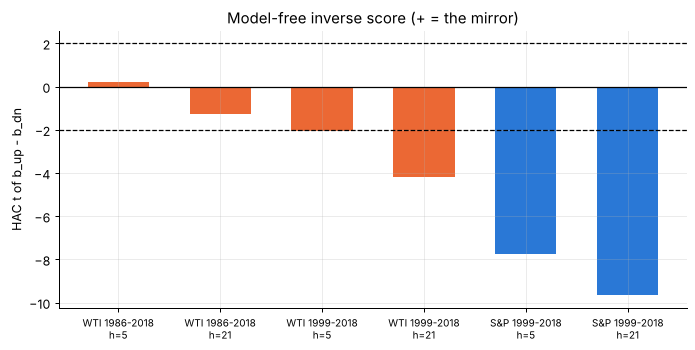

b_up  b_dn  t(b_up-b_dn)   corr  corr_lo  corr_hi  \
tape          h                                                        
WTI 1986-2018 5   1.530 1.462         0.219 -0.017   -0.056    0.020   
              21  0.796 1.082        -1.283 -0.040   -0.071   -0.010   
WTI 1999-2018 5   0.767 1.394        -2.070 -0.053   -0.092   -0.013   
              21  0.371 1.091        -4.201 -0.068   -0.106   -0.028   
S&P 1999-2018 5  -0.259 2.222        -7.728 -0.150   -0.193   -0.107   
              21  0.222 1.941        -9.665 -0.118   -0.153   -0.073   

                  matched_up/down  
tape          h                    
WTI 1986-2018 5             0.970  
              21            0.968  
WTI 1999-2018 5             0.930  
              21            0.945  
S&P 1999-2018 5             0.880  
              21            0.915

In [4]:
rows = []
for lab, r in (("WTI 1986-2018", rw), ("WTI 1999-2018", rw99), ("S&P 1999-2018", rs)):
    for h in (5, 21):
        m = st.forward_vol_regression(r, h)
        c = st.sign_correlation(r, h, n_boot=300)
        rows.append({"tape": lab, "h": h, "b_up": m["b_up"], "b_dn": m["b_dn"],
                     "t(b_up-b_dn)": m["diff_t"], "corr": c["corr"], "corr_lo": c["lo"],
                     "corr_hi": c["hi"], "matched_up/down": c["matched_up_over_down"]})
mf = pd.DataFrame(rows).set_index(["tape", "h"])
fig, ax = plt.subplots(figsize=(9, 4))
lab = [f"{a}\nh={b}" for a, b in mf.index]
ax.bar(range(len(mf)), mf["t(b_up-b_dn)"],
       color=[OIL if "WTI" in a else EQ for a, _ in mf.index], width=0.6)
ax.axhline(2, color="k", ls="--", lw=1); ax.axhline(-2, color="k", ls="--", lw=1)
ax.axhline(0, color="k", lw=1)
ax.set_xticks(range(len(mf))); ax.set_xticklabels(lab, fontsize=8)
ax.set_ylabel("HAC t of b_up - b_dn"); ax.set_title("Model-free inverse score (+ = the mirror)")
plt.show(); mf.round(3)

`RV(t+1..t+h) = a + b_up·r⁺_t + b_dn·|r⁻_t| + c·RV21(t)`, Newey-West with *h* lags. The full
WTI sample is equity-signed but sub-bar at *h* = 21; 1999-2018 is equity-signed and
significant. The bootstrap correlation interval (blocks ≥ 21 days) agrees in sign.

> 💡 **In plain words:** without any model at all, oil after an up day is slightly
> calmer than after a down day of the same size — the stock pattern, faintly.

### 3.3 Property or regime?

GJR gamma difference (late - early) +0.0595, se 0.0176, z +3.38


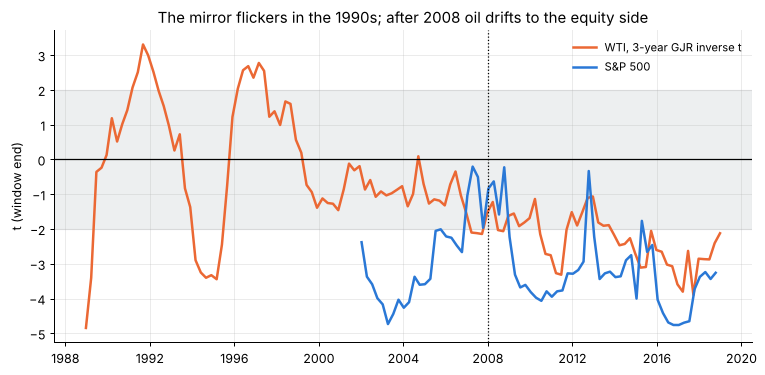

windows with inverse t >= 2: 9%; with t <= -2: 33%


,start,end,n,gjr_gamma,gjr_se,gjr_inv_t,egarch_gamma,egarch_inv_t,mf_diff,mf_t,ann_vol
era,,,,,,,,,,,
1986-2007,1986-01-03,2007-12-31,5550,0.002,0.012,-0.151,-0.011,-1.254,0.113,0.410,0.402
2008-2018,2008-01-02,2018-12-28,2768,0.061,0.013,-4.812,-0.063,-6.843,-1.158,-4.653,0.390


In [5]:
eras = {"1986-2007": ("1986-01-01", "2007-12-31"), "2008-2018": ("2008-01-01", "2018-12-31")}
tbl = st.era_table(rw, eras)
d = st.era_difference(tbl, "1986-2007", "2008-2018")
print(f"GJR gamma difference (late - early) {d['diff']:+.4f}, se {d['se']:.4f}, z {d['z']:+.2f}")
roll = st.rolling_asymmetry(rw, window=756, step=63)
roll_sp = st.rolling_asymmetry(rs, window=756, step=63)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(roll.index, roll["inv_t"], color=OIL, lw=2, label="WTI, 3-year GJR inverse t")
ax.plot(roll_sp.index, roll_sp["inv_t"], color=EQ, lw=2, label="S&P 500")
ax.axhspan(-2, 2, color=NULL, alpha=0.15); ax.axhline(0, color="k", lw=1)
ax.axvline(pd.Timestamp("2008-01-01"), color="k", ls=":", lw=1)
ax.set_ylabel("t (window end)"); ax.legend(frameon=False, fontsize=9)
ax.set_title("The mirror flickers in the 1990s; after 2008 oil drifts to the equity side")
plt.show()
print(f"windows with inverse t >= 2: {(roll.inv_t >= 2).mean():.0%}; "
      f"with t <= -2: {(roll.inv_t <= -2).mean():.0%}")
tbl.round(3)

The pre-registered split shows **no** era with the mirror at the bar; the difference between
eras is significant (z ≈ +3.4) but it runs *from symmetric to equity-like*.
The rolling windows (overlapping, descriptive, not used for the stamp) show the only
inverse stretches around the 1990-91 Gulf War and the 1996 inventory squeeze.

> 💡 **In plain words:** a big supply shock can briefly make rallies the scary
> direction for oil. It is not the normal state, and since 2008 the opposite has been true.

### 3.4 Skewness

In [6]:
wm = data.log_returns(wti.resample("ME").last()); sm_ = data.log_returns(sp.resample("ME").last())
bm = data.log_returns(data.load_crude_monthly()["brent"])
rows = []
for lab, r, blk in (("WTI daily 1986-2018", rw, 21), ("WTI daily 1999-2018", rw99, 21),
                    ("S&P daily 1999-2018", rs, 21), ("WTI month-end", wm, 6),
                    ("S&P month-end", sm_, 6), ("Brent monthly avg", bm, 6)):
    s = st.skew_ci(r, n_boot=300, block=blk)
    rows.append({"series": lab, **s})
sk = pd.DataFrame(rows).set_index("series")
print(st.skew_difference(rw99, rs, n_boot=300))
sk.round(3)

{'diff': 0.04576888388414996, 'lo': -0.3212878663222833, 'hi': 0.46911962315241185, 'p': 0.84, 'n': 5011}


,skew,lo,hi,quantile_skew,n
series,,,,,
WTI daily 1986-2018,-0.652,-1.530,-0.021,-0.041,8318
WTI daily 1999-2018,-0.162,-0.400,0.058,-0.051,5020
S&P daily 1999-2018,-0.205,-0.488,0.121,-0.070,5030
WTI month-end,-0.135,-0.657,0.412,-0.090,395
S&P month-end,-0.753,-1.192,-0.284,-0.218,239
Brent monthly avg,-0.202,-0.924,0.587,-0.183,391


A mirror asset should be positively skewed. WTI is not: its moment skew is negative (driven by
a handful of crash days — 17 January 1991 is −33% in log terms) and its quantile skew is close
to the S&P's; the daily skew difference on common dates is indistinguishable from zero.

### 3.5 Monthly Brent cross-check (monthly *averages* — direction only)

In [7]:
cr = data.load_crude_monthly()
pd.DataFrame({c: st.monthly_asymmetry(cr[c]) for c in cr.columns}).T.round(3)

,b_up,b_dn,diff,diff_se,diff_t,n
brent,0.151,0.325,-0.174,0.103,-1.686,388.000
wti,0.054,0.234,-0.180,0.091,-1.984,388.000


Same sign as the daily tape, short of the bar. Averaging smooths returns (Working 1960), so
the power here is low by construction.

## 4 · The verdict

The pre-registered rule returns **Signal: None** (neither lens ≥ 2 on the
inverse side; no era at the bar) and **Tradability: Mirage** (below).

In [8]:
import json, re
txt = open("../docs/results.md", encoding="utf-8").read()
print(txt[txt.index("## Verdict"):txt.index("---", txt.index("## Verdict"))])

## Verdict

Produced by `strategy.verdict`, fixed before the run and unit-tested in
[`tests/test_strategy.py`](../tests/test_strategy.py).

**Signal: None.** Neither lens sees the mirror on this tape. Full-sample WTI spot: GJR inverse score t = **-2.62** (EGARCH -4.40), model-free forward-vol regression t = **-1.28** at 21 days (+0.22 at 5); the S&P 500 mirror reads GJR t = -8.10, the textbook equity sign. By era: 1986-2007 t = -0.15; 2008-2018 t = -4.81; the era difference in GJR gamma has z = **+3.38**. Monthly-average Brent cross-check t = -1.69 (direction only). Positive = volatility rises after rallies. A rolling three-year GJR (descriptive, overlapping windows) clears +2 in only 9% of windows — none ending after 1997 — against 33% at -2 or below.

**Tradability: Mirage.** Capped by the tape: WTI here is a **spot** price, not an investable futures return. On that spot proxy, a 21-day vol-target overlay (one lag, 10 bp one-way) moves the excess Sharpe from 0.27 to 0.19 net (gain -0

## 5 · Could you trade it? The vol-target overlay

`w_t = min(2, target_t / RV21_t)`, past-only expanding target; **one execution lag**
(weight at close *t* earns *t+1*); costs one-way × |Δw|; excess-vs-excess (S&P minus T-bill;
the WTI spot change treated as a collateralised futures-proxy excess return).

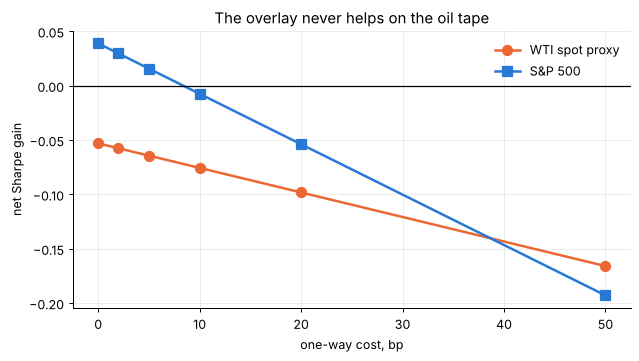

,cost_bps,sharpe_bh,sharpe_gross,sharpe_net,gain_net,gain_lo,gain_hi,mdd_bh,mdd_net,turnover_ann,react_corr,breakeven_bps
WTI 1987-2018,10.000,0.267,0.214,0.191,-0.076,-0.219,0.066,-0.820,-0.859,8.823,0.038,0.000
WTI 1999-2018,10.000,0.258,0.242,0.218,-0.039,-0.198,0.144,-0.820,-0.862,9.446,0.156,0.000
S&P 1999-2018,5.000,0.201,0.240,0.216,0.016,-0.168,0.214,-0.658,-0.639,8.847,0.308,8.398


In [9]:
rf = data.load_rf_daily(sp.index)
sw, ss = data.simple_returns(wti), data.simple_returns(sp)
res = {}
for key, r, rfx, c in (("WTI 1987-2018", sw, None, 10.0),
                       ("WTI 1999-2018", sw[sw.index >= sp.index[0]], None, 10.0),
                       ("S&P 1999-2018", ss, rf, 5.0)):
    o = st.vol_target_overlay(r, rfx, cost_bps=c, n_boot=500)
    o.pop("series")
    res[key] = o
ov = pd.DataFrame(res).T[["cost_bps", "sharpe_bh", "sharpe_gross", "sharpe_net", "gain_net",
                          "gain_lo", "gain_hi", "mdd_bh", "mdd_net", "turnover_ann",
                          "react_corr", "breakeven_bps"]]
cs = pd.concat({"WTI": st.cost_sweep(sw, None)["gain_net"],
                "S&P": st.cost_sweep(ss, rf)["gain_net"]}, axis=1)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(cs.index, cs["WTI"], "o-", color=OIL, lw=2, ms=8, label="WTI spot proxy")
ax.plot(cs.index, cs["S&P"], "s-", color=EQ, lw=2, ms=8, label="S&P 500")
ax.axhline(0, color="k", lw=1); ax.set_xlabel("one-way cost, bp"); ax.set_ylabel("net Sharpe gain")
ax.legend(frameon=False); ax.set_title("The overlay never helps on the oil tape")
plt.show(); ov.astype(float).round(3)

On the S&P the thermostat de-risks after falls (reaction +0.3) and adds a small, statistically
unresolved gain before costs. On WTI the reaction is near zero over the full sample — oil's
volatility responds to the size of a move, not its sign — and the overlay loses Sharpe even
gross. Nowhere does the thermostat de-risk after rallies. Capacity is moot: the tape is spot,
and a real futures book adds a roll the spot ignores.

> 💡 **In plain words:** the famous risk-dial behaves on oil the way it does on stocks,
> only more weakly, and on this tape it would have cost you.

## 6 · Going further

- **Futures, with the roll.** The investable version; it would also extend the sample through
  April 2020's negative settlement.
- **Event conditioning.** Replace calendar eras by identified supply vs demand shocks (e.g. a
  structural oil-market VAR decomposition) and test whether the asymmetry follows the *shock
  type* — the mechanism the claim actually proposes.
- **Gold and other commodities**, where the inverse asymmetry has the strongest published
  support; see neighbour study 993 for gold's ratio.
- **Realised-measure GARCH** (HEAVY / realised GARCH) on intraday futures data would sharpen
  the model-free lens considerably.